# Sobre o Notebook


Este notebook realiza análises estatísticas e gera visualizações a partir das respostas da *survey*, na qual participantes avaliaram mensagens provenientes de conversas reais e de conversas simuladas. As análises permitem comparar a percepção dos participantes em relação a aspectos como naturalidade, legibilidade e formalidade das mensagens.

---

## Requisitos

Para executar este notebook, são necessários os seguintes arquivos:

1. **`survey_results.xlsx`**: arquivo contendo as respostas dos participantes da *survey*.

2. **`60_sample_messages.csv`**: arquivo contendo as 60 mensagens avaliadas na *survey*, juntamente com a origem de cada uma:
   - **`NS`**: mensagem gerada pelo *Network Simulator*;
   - **`T16`**: mensagem proveniente do conjunto de dados **Twitter16**.

Os dois arquivos devem ser enviados diretamente para o ambiente de execução do Google Colab antes da execução do notebook.

---

# Configuração do Ambiente

In [1]:
!pip install statsmodels

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, mannwhitneyu

In [3]:
# Show all columns
pd.set_option('display.max_columns', None)

# Criando as Tabelas

Tabela de respostas da Survey

In [4]:
# Create table
file_path = "/content/survey_results.xlsx"
df = pd.read_excel(file_path)

# View
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head(3))

Linhas: 21
Colunas: 186


,Carimbo de data/hora,Você leu e concorda com o TCLE?\nHave you read and do you agree to the Informed Consent Form?,Idade | Age,Proficiência em Inglês | English Proficiency,"Nível de familiaridade com ferramentas de IA generativa (ex. ChatGPT)\nHow familiar are you with generative AI tools (e.g., ChatGPT)?",Formalidade | Formality,Legibilidade | Readability,Naturalidade | Naturalness,Coluna 8,Coluna 9,Coluna 10,Coluna 11,Coluna 12,Coluna 13,Coluna 14,Coluna 15,Coluna 16,Coluna 17,Coluna 18,Coluna 19,Formalidade | Formality 2,Legibilidade | Readability 2,Naturalidade | Naturalness 2,Coluna 23,Coluna 24,Coluna 25,Coluna 26,Coluna 27,Coluna 28,Coluna 29,Coluna 30,Coluna 31,Coluna 32,Coluna 33,Coluna 34,Formalidade | Formality 3,Legibilidade | Readability 3,Naturalidade | Naturalness 3,Coluna 38,Coluna 39,Coluna 40,Coluna 41,Coluna 42,Coluna 43,Coluna 44,Coluna 45,Coluna 46,Coluna 47,Coluna 48,Coluna 49,Formalidade | Formality 4,Legibilidade | Readability 4,Naturalidade | Naturalness 4,Coluna 53,Coluna 54,Coluna 55,Coluna 56,Coluna 57,Coluna 58,Coluna 59,Coluna 60,Coluna 61,Coluna 62,Coluna 63,Coluna 64,Formalidade | Formality 5,Legibilidade | Readability 5,Naturalidade | Naturalness 5,Coluna 68,Coluna 69,Coluna 70,Coluna 71,Coluna 72,Coluna 73,Coluna 74,Coluna 75,Coluna 76,Coluna 77,Coluna 78,Coluna 79,Formalidade | Formality 6,Legibilidade | Readability 6,Naturalidade | Naturalness 6,Coluna 83,Coluna 84,Coluna 85,Coluna 86,Coluna 87,Coluna 88,Coluna 89,Coluna 90,Coluna 91,Coluna 92,Coluna 93,Coluna 94,Formalidade | Formality 7,Legibilidade | Readability 7,Naturalidade | Naturalness 7,Coluna 98,Coluna 99,Coluna 100,Coluna 101,Coluna 102,Coluna 103,Coluna 104,Coluna 105,Coluna 106,Coluna 107,Coluna 108,Coluna 109,Formalidade | Formality 8,Legibilidade | Readability 8,Naturalidade | Naturalness 8,Coluna 113,Coluna 114,Coluna 115,Coluna 116,Coluna 117,Coluna 118,Coluna 119,Coluna 120,Coluna 121,Coluna 122,Coluna 123,Coluna 124,Formalidade | Formality 9,Legibilidade | Readability 9,Naturalidade | Naturalness 9,Coluna 128,Coluna 129,Coluna 130,Coluna 131,Coluna 132,Coluna 133,Coluna 134,Coluna 135,Coluna 136,Coluna 137,Coluna 138,Coluna 139,Formalidade | Formality 10,Legibilidade | Readability 10,Naturalidade | Naturalness 10,Coluna 143,Coluna 144,Coluna 145,Coluna 146,Coluna 147,Coluna 148,Coluna 149,Coluna 150,Coluna 151,Coluna 152,Coluna 153,Coluna 154,Formalidade | Formality 11,Legibilidade | Readability 11,Naturalidade | Naturalness 11,Coluna 158,Coluna 159,Coluna 160,Coluna 161,Coluna 162,Coluna 163,Coluna 164,Coluna 165,Coluna 166,Coluna 167,Coluna 168,Coluna 169,Formalidade | Formality 12,Legibilidade | Readability 12,Naturalidade | Naturalness 12,Coluna 173,Coluna 174,Coluna 175,Coluna 176,Coluna 177,Coluna 178,Coluna 179,Coluna 180,Coluna 181,Coluna 182,Coluna 183,Coluna 184,Quais características das mensagens mais influenciaram suas avaliações?\nWhich characteristics of the messages most influenced your ratings?
0,2026-06-30 15:19:45.554,Sim,18-24,Fluente,Uso com frequência | Regular user,3,3,2,3,4,1,2,2,3,2,2,4,3,4,4,3,2,4,4,4,4,2,2,4,2,4,2,3,4,4,2,2,3,4,4,4,2,2,4,4,4,1,1,1,5,2,4,2,3,3,3,2,4,3,3,3,4,3,3,2,3,1,4,1,5,3,3,2,4,3,3,4,2,3,3,2,4,5,2,4,2,2,2,3,2,4,3,3,3,4,3,4,2,3,4,2,1,4,4,3,3,4,2,4,2,2,3,4,3,2,3,3,2,3,3,3,3,3,4,2,2,3,4,3,4,3,2,4,3,2,4,4,3,3,3,3,4,4,2,4,4,3,4,2,3,3,4,3,3,3,3,4,2,3,4,3,4,3,4,3,4,3,3,4,3,4,1,5,2,4,4,2,4,4,4,2,3,3,2,4,"A intensidade de cada mensagem, além de elemen..."
1,2026-07-01 10:35:39.079,Sim,18-24,Fluente,Usei poucas vezes | I used it a few times,4,5,2,3,5,2,3,4,4,2,5,4,2,5,1,2,5,4,4,4,4,2,2,3,2,4,1,2,4,4,2,1,2,2,4,4,2,4,5,2,5,1,3,5,2,2,5,1,2,5,2,2,5,2,1,1,2,1,5,1,3,5,4,2,5,2,2,2,1,2,5,2,2,5,1,2,5,5,2,5,1,4,5,1,3,5,1,3,5,5,3,5,1,5,5,1,4,5,5,5,4,1,2,5,2,2,5,5,3,5,2,1,2,5,1,5,5,4,5,2,2,5,2,5,5,1,2,5,1,4,5,1,3,4,3,2,2,3,1,5,5,5,5,1,2,5,5,2,5,4,1,5,1,2,5,4,2,5,5,3,5,2,2,5,4,1,5,5,3,5,5,1,5,5,1,5,5,2,4,5,Pontuação; O uso de emojis de forma decorativa...
2,2026-07-01 20:47:29.040,Sim,18-24,Fluente,U

Separando respostas da Survey em:
*   Informações do participante e comentário final
*   Notas dos comentários pelo participante



In [5]:
# Table 1 - Participant information and final comment
# Columns 1 to 5 + last column (186)
df_info = pd.concat(
    [df.iloc[:, :5], df.iloc[:, -1:]],
    axis=1
)

# Table 2 - Comment Ratings
# Remaining columns (6th through the second-to-last)
df_ratings = df.iloc[:, 5:-1]

# View
print("df_info:", df_info.shape)
print("df_ratings:", df_ratings.shape)

display(df_info.head(3))
display(df_ratings.head(3))

df_info: (21, 6)
df_ratings: (21, 180)


,Carimbo de data/hora,Você leu e concorda com o TCLE?\nHave you read and do you agree to the Informed Consent Form?,Idade | Age,Proficiência em Inglês | English Proficiency,"Nível de familiaridade com ferramentas de IA generativa (ex. ChatGPT)\nHow familiar are you with generative AI tools (e.g., ChatGPT)?",Quais características das mensagens mais influenciaram suas avaliações?\nWhich characteristics of the messages most influenced your ratings?
0,2026-06-30 15:19:45.554,Sim,18-24,Fluente,Uso com frequência | Regular user,"A intensidade de cada mensagem, além de elemen..."
1,2026-07-01 10:35:39.079,Sim,18-24,Fluente,Usei poucas vezes | I used it a few times,Pontuação; O uso de emojis de forma decorativa...
2,2026-07-01 20:47:29.040,Sim,18-24,Fluente,Uso com frequência | Regular user,Pontuação e uso de emojis.


,Formalidade | Formality,Legibilidade | Readability,Naturalidade | Naturalness,Coluna 8,Coluna 9,Coluna 10,Coluna 11,Coluna 12,Coluna 13,Coluna 14,Coluna 15,Coluna 16,Coluna 17,Coluna 18,Coluna 19,Formalidade | Formality 2,Legibilidade | Readability 2,Naturalidade | Naturalness 2,Coluna 23,Coluna 24,Coluna 25,Coluna 26,Coluna 27,Coluna 28,Coluna 29,Coluna 30,Coluna 31,Coluna 32,Coluna 33,Coluna 34,Formalidade | Formality 3,Legibilidade | Readability 3,Naturalidade | Naturalness 3,Coluna 38,Coluna 39,Coluna 40,Coluna 41,Coluna 42,Coluna 43,Coluna 44,Coluna 45,Coluna 46,Coluna 47,Coluna 48,Coluna 49,Formalidade | Formality 4,Legibilidade | Readability 4,Naturalidade | Naturalness 4,Coluna 53,Coluna 54,Coluna 55,Coluna 56,Coluna 57,Coluna 58,Coluna 59,Coluna 60,Coluna 61,Coluna 62,Coluna 63,Coluna 64,Formalidade | Formality 5,Legibilidade | Readability 5,Naturalidade | Naturalness 5,Coluna 68,Coluna 69,Coluna 70,Coluna 71,Coluna 72,Coluna 73,Coluna 74,Coluna 75,Coluna 76,Coluna 77,Coluna 78,Coluna 79,Formalidade | Formality 6,Legibilidade | Readability 6,Naturalidade | Naturalness 6,Coluna 83,Coluna 84,Coluna 85,Coluna 86,Coluna 87,Coluna 88,Coluna 89,Coluna 90,Coluna 91,Coluna 92,Coluna 93,Coluna 94,Formalidade | Formality 7,Legibilidade | Readability 7,Naturalidade | Naturalness 7,Coluna 98,Coluna 99,Coluna 100,Coluna 101,Coluna 102,Coluna 103,Coluna 104,Coluna 105,Coluna 106,Coluna 107,Coluna 108,Coluna 109,Formalidade | Formality 8,Legibilidade | Readability 8,Naturalidade | Naturalness 8,Coluna 113,Coluna 114,Coluna 115,Coluna 116,Coluna 117,Coluna 118,Coluna 119,Coluna 120,Coluna 121,Coluna 122,Coluna 123,Coluna 124,Formalidade | Formality 9,Legibilidade | Readability 9,Naturalidade | Naturalness 9,Coluna 128,Coluna 129,Coluna 130,Coluna 131,Coluna 132,Coluna 133,Coluna 134,Coluna 135,Coluna 136,Coluna 137,Coluna 138,Coluna 139,Formalidade | Formality 10,Legibilidade | Readability 10,Naturalidade | Naturalness 10,Coluna 143,Coluna 144,Coluna 145,Coluna 146,Coluna 147,Coluna 148,Coluna 149,Coluna 150,Coluna 151,Coluna 152,Coluna 153,Coluna 154,Formalidade | Formality 11,Legibilidade | Readability 11,Naturalidade | Naturalness 11,Coluna 158,Coluna 159,Coluna 160,Coluna 161,Coluna 162,Coluna 163,Coluna 164,Coluna 165,Coluna 166,Coluna 167,Coluna 168,Coluna 169,Formalidade | Formality 12,Legibilidade | Readability 12,Naturalidade | Naturalness 12,Coluna 173,Coluna 174,Coluna 175,Coluna 176,Coluna 177,Coluna 178,Coluna 179,Coluna 180,Coluna 181,Coluna 182,Coluna 183,Coluna 184
0,3,3,2,3,4,1,2,2,3,2,2,4,3,4,4,3,2,4,4,4,4,2,2,4,2,4,2,3,4,4,2,2,3,4,4,4,2,2,4,4,4,1,1,1,5,2,4,2,3,3,3,2,4,3,3,3,4,3,3,2,3,1,4,1,5,3,3,2,4,3,3,4,2,3,3,2,4,5,2,4,2,2,2,3,2,4,3,3,3,4,3,4,2,3,4,2,1,4,4,3,3,4,2,4,2,2,3,4,3,2,3,3,2,3,3,3,3,3,4,2,2,3,4,3,4,3,2,4,3,2,4,4,3,3,3,3,4,4,2,4,4,3,4,2,3,3,4,3,3,3,3,4,2,3,4,3,4,3,4,3,4,3,3,4,3,4,1,5,2,4,4,2,4,4,4,2,3,3,2,4
1,4,5,2,3,5,2,3,4,4,2,5,4,2,5,1,2,5,4,4,4,4,2,2,3,2,4,1,2,4,4,2,1,2,2,4,4,2,4,5,2,5,1,3,5,2,2,5,1,2,5,2,2,5,2,1,1,2,1,5,1,3,5,4,2,5,2,2,2,1,2,5,2,2,5,1,2,5,5,2,5,1,4,5,1,3,5,1,3,5,5,3,5,1,5,5,1,4,5,5,5,4,1,2,5,2,2,5,5,3,5,2,1,2,5,1,5,5,4,5,2,2,5,2,5,5,1,2,5,1,4,5,1,3,4,3,2,2,3,1,5,5,5,5,1,2,5,5,2,5,4,1,5,1,2,5,4,2,5,5,3,5,2,2,5,4,1,5,5,3,5,5,1,5,5,1,5,5,2,4,5
2,3,4,4,3,5,2,3,1,4,2,5,3,3,5,4,3,3,5,4,4,4,2,2,4,3,4,3,4,5,3,3,3,4,4,5,4,2,3,4,4,5,2,3,3,4,3,5,3,3,5,4,2,5,3,3,5,5,3,5,2,4,5,4,3,5,4,4,3,4,4,5,4,3,5,4,4,5,4,3,5,3,3,5,2,3,5,2,4,5,4,3,4,3,3,5,2,3,4,4,4,4,4,3,4,3,4,4,4,4,5,4,3,3,5,4,5,5,4,4,2,4,5,4,3,5,2,3,5,2,3,4,2,4,3,4,3,3,4,3,4,4,3,4,2,4,4,3,3,5,2,3,5,2,3,5,3,4,3,5,3,4,3,3,4,3,2,3,4,3,4,3,3,4,4,1,3,5,3,4,4


Tabela com a origem das mensagens da Survey (NS ou T16)

In [6]:
# Create table
arquivo_csv = "/content/60_sample_messages.csv"
df_messages = pd.read_csv(arquivo_csv)

# View
print(f"Linhas: {df_messages.shape[0]}")
print(f"Colunas: {df_messages.shape[1]}")

display(df_messages.head())

Linhas: 60
Colunas: 2


,text,origin
0,Zelenskyy in PA? 🤔 Sounds fishy to me! Why's h...,NS
1,"I mean, both have their own charm, right? 🎭 Se...",NS
2,#BREAKING Gunman in policewoman killing suspec...,T16
3,@user @user @user Thank u! I admire any journa...,T16
4,"Wait, is this true? 😮 I thought Laila Ali was ...",NS


Tabela final com:
*   Participante
*   Comentário (texto) e origem (NS ou T16)
*   Notas (Formalidade, Legibilidade, Naturalidade)

In [7]:
# Create table
rows = []

n_messages = len(df_messages)
n_participants = len(df_ratings)

for participant in range(n_participants):
    for msg in range(n_messages):
        rows.append({
            "participant": participant + 1,
            "message": msg,
            "text": df_messages.loc[msg, "text"],
            "origin": df_messages.loc[msg, "origin"],
            "formality": df_ratings.iloc[participant, msg * 3],
            "readability": df_ratings.iloc[participant, msg * 3 + 1],
            "naturalness": df_ratings.iloc[participant, msg * 3 + 2],
        })

df_messages_metrics = pd.DataFrame(rows)

# View
print(df_messages_metrics.shape) # (N Participants * 60, 7)
display(df_messages_metrics)

(1260, 7)


,participant,message,text,origin,formality,readability,naturalness
0,1,0,Zelenskyy in PA? 🤔 Sounds fishy to me! Why's h...,NS,3,3,2
1,1,1,"I mean, both have their own charm, right? 🎭 Se...",NS,3,4,1
2,1,2,#BREAKING Gunman in policewoman killing suspec...,T16,2,2,3
3,1,3,@user @user @user Thank u! I admire any journa...,T16,2,2,4
4,1,4,"Wait, is this true? 😮 I thought Laila Ali was ...",NS,3,4,4
...,...,...,...,...,...,...,...
1255,21,55,"@user#Obama has made us weak,in the eyes of th...",T16,1,1,1
1256,21,56,"Lol, like Elon would say that! 😂 Tesla's not g...",NS,3,3,3
1257,21,57,"Nah, I don't buy it. Wisconsin universities ca...",NS,1,4,4
1258,21,58,"@user @user BS, 90 day numbers, back 2 school ...",T16,2,3,3


# Representações Visuais

Boxplots:

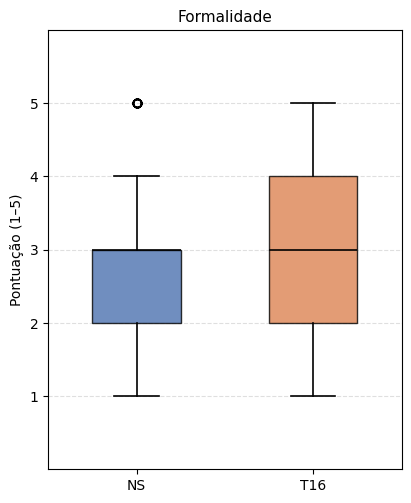

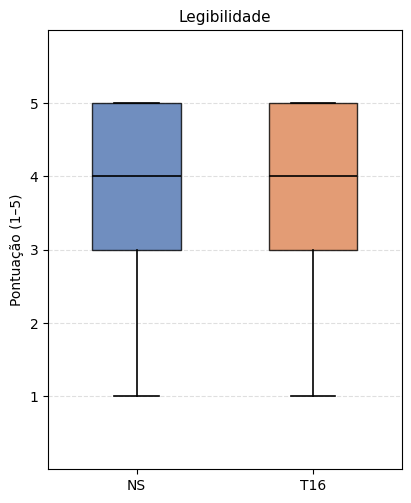

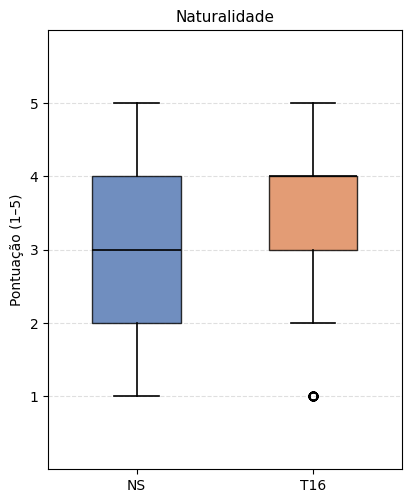

In [8]:
metrics = [
    ("formality", "Formalidade"),
    ("readability", "Legibilidade"),
    ("naturalness", "Naturalidade"),
]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for column, title in metrics:

    fig, ax = plt.subplots(
        figsize=(4, 5),
        constrained_layout=True
    )

    # Create Boxplot
    df_messages_metrics.boxplot(
        column=column,
        by="origin",
        ax=ax,
        grid=False,
        widths=0.5,
        patch_artist=True,
    )

    # Color the boxes
    for patch, color in zip(ax.patches, colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_alpha(0.8)

    # Line style
    for line in ax.lines:
        line.set_color("black")
        line.set_linewidth(1.2)

    fig.suptitle("")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Pontuação (1–5)")
    ax.set_ylim(0, 6)
    ax.set_yticks([1, 2, 3, 4, 5])

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()

Violin Plots:

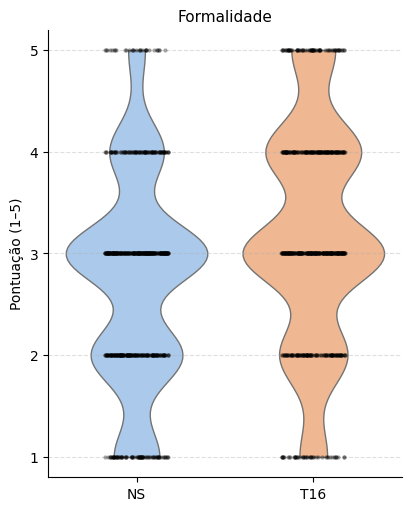

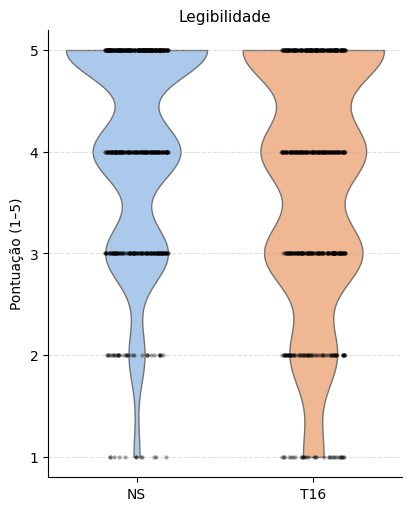

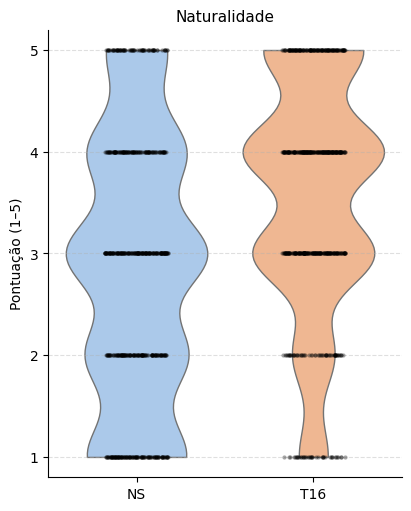

In [9]:
palette = "pastel"

for column, title in metrics:

    fig, ax = plt.subplots(
        figsize=(4, 5),
        constrained_layout=True
    )

    # Violin plot
    sns.violinplot(
        data=df_messages_metrics,
        x="origin",
        y=column,
        hue="origin",          # <- adicionado
        palette=palette,
        legend=False,          # <- adicionado
        inner=None,
        cut=0,
        linewidth=1,
        ax=ax,
    )

    # Individual observations
    sns.stripplot(
        data=df_messages_metrics,
        x="origin",
        y=column,
        color="black",
        size=3,
        alpha=0.35,
        jitter=0.18,
        ax=ax,
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Pontuação (1–5)")
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    sns.despine()
    plt.show()

Histogramas:

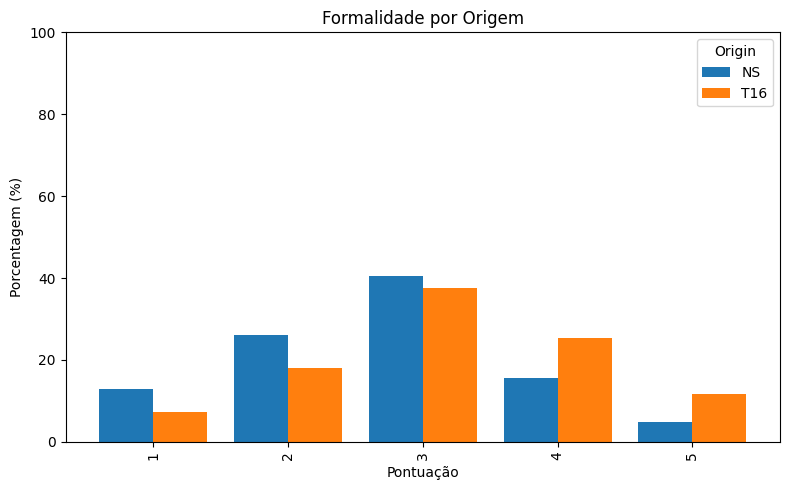

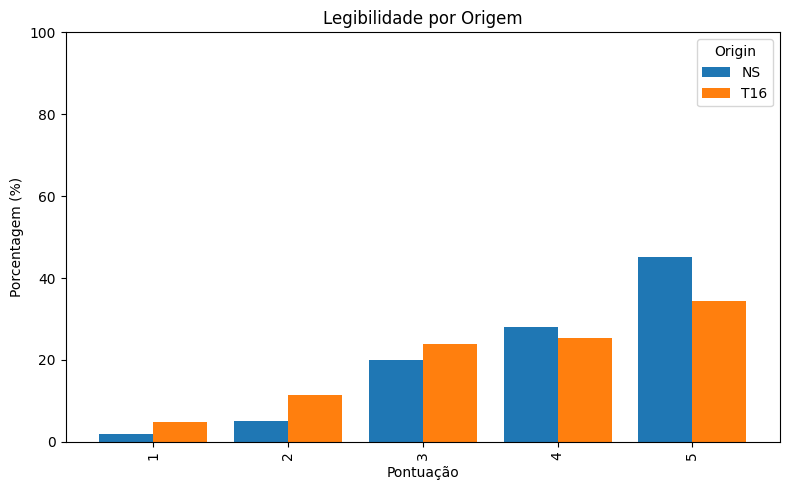

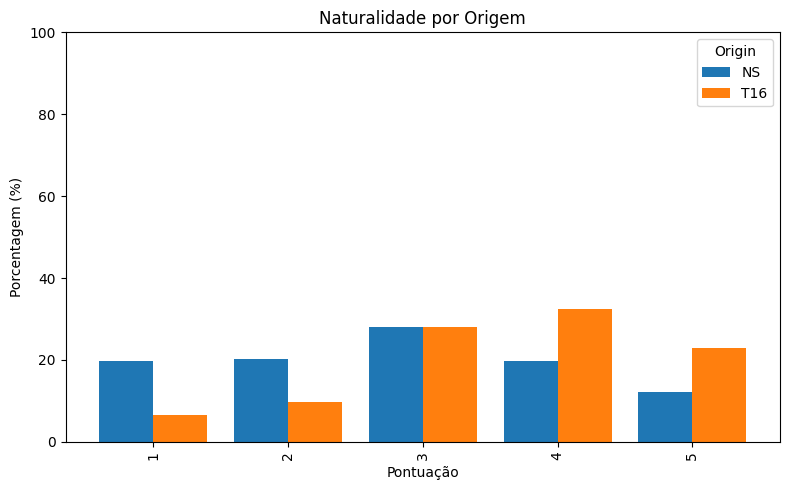

In [10]:
for metric in metrics:

    # Count of ratings by origin
    counts = (
        df_messages_metrics
        .groupby(["origin", metric[0]])
        .size()
        .unstack(fill_value=0)
    )

    counts = counts.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)

    # Convert to percentage
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100

    # Plot
    ax = percentages.T.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    ax.set_title(f"{metric[1].capitalize()} por Origem")
    ax.set_xlabel(f"Pontuação")
    ax.set_ylabel("Porcentagem (%)")
    ax.legend(title="Origin")
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

# Comparações Estatísticas

Estatísticas descritivas

In [11]:
# Descriptive statistics for the selected features
summary = (
    df_messages_metrics
    .groupby("origin")[["formality", "readability", "naturalness"]]
    .agg([
        "mean",
        lambda x: x.quantile(0.25),                       # 25%
        "median",
        lambda x: ", ".join(map(str, x.mode().tolist())), # Mode
        lambda x: x.quantile(0.75),                       # 75%
        "std"
    ])
    .round(2)
)

# Rename lambda function columns
summary.columns = pd.MultiIndex.from_tuples([
    (
        metric,
        {
            "<lambda_0>": "25%",
            "<lambda_1>": "mode",
            "<lambda_2>": "75%"
        }.get(stat, stat)
    )
    for metric, stat in summary.columns
])

display(summary)

formality                             readability                   \
            mean  25% median mode  75%   std        mean  25% median mode   
origin                                                                      
NS          2.73  2.0    3.0    3  3.0  1.03        4.09  3.0    4.0    5   
T16         3.16  2.0    3.0    3  4.0  1.08        3.73  3.0    4.0    5   

                  naturalness                              
        75%   std        mean  25% median mode  75%   std  
origin                                                     
NS      5.0  1.01        2.84  2.0    3.0    3  4.0  1.29  
T16     5.0  1.19        3.56  3.0    4.0    4  4.0  1.14

Teste de Mann–Whitney U

In [12]:
metrics = ["formality", "readability", "naturalness"]

results = []

# Perform the Mann-Whitney U test for each metric
for metric in metrics:

    human = df_messages_metrics[df_messages_metrics["origin"] == "T16"][metric]
    llm   = df_messages_metrics[df_messages_metrics["origin"] == "NS"][metric]

    # Compare the distributions using a two-sided Mann-Whitney U test
    stat, p = mannwhitneyu(
        human,
        llm,
        alternative="two-sided"
    )

    results.append({
        "Metric": metric,
        "U statistic": round(stat,2),
        "p-value": p,
        "Significant": p < 0.05
    })

results = pd.DataFrame(results)

display(results)

,Metric,U statistic,p-value,Significant
0,formality,242450.5,1.200039e-12,True
1,readability,165428.0,7.929603e-08,True
2,naturalness,261299.5,1.681878e-23,True


Teste de Wilcoxon

In [13]:
# Compute the mean score for each participant and dataset
participant_means = (
    df_messages_metrics
    .groupby(["participant", "origin"])[
        ["formality", "readability", "naturalness"]
    ]
    .mean()
    .reset_index()
)

display(participant_means.head())

,participant,origin,formality,readability,naturalness
0,1,NS,2.500000,3.800000,2.666667
1,1,T16,2.800000,2.633333,3.866667
2,2,NS,2.700000,4.966667,1.966667
3,2,T16,2.166667,4.066667,3.700000
4,3,NS,3.033333,4.600000,2.800000


In [14]:
# Reshape the data to create paired observations for each participant
participant_paired = participant_means.pivot(
    index="participant",
    columns="origin",
    values=["formality", "readability", "naturalness"]
)

display(participant_paired.head())

formality           readability           naturalness          
origin             NS       T16          NS       T16          NS       T16
participant                                                                
1            2.500000  2.800000    3.800000  2.633333    2.666667  3.866667
2            2.700000  2.166667    4.966667  4.066667    1.966667  3.700000
3            3.033333  3.333333    4.600000  3.833333    2.800000  4.100000
4            2.066667  3.600000    4.366667  4.100000    3.033333  3.366667
5            2.900000  3.066667    3.100000  3.000000    2.900000  2.933333

In [15]:
metrics = ["formality", "readability", "naturalness"]

results = []

# Perform the Wilcoxon signed-rank test for each paired metric
for metric in metrics:

    t16 = participant_paired[(metric, "T16")]
    ns  = participant_paired[(metric, "NS")]

    # Compare paired samples using a two-sided Wilcoxon signed-rank test
    statistic, p = wilcoxon(
        t16,
        ns,
        alternative="two-sided"
    )

    results.append({
        "Metric": metric,
        "Statistic": statistic,
        "p-value": p,
        "Result": "Significant" if p < 0.05 else "Not Significant"
    })

results = pd.DataFrame(results)

display(results)

,Metric,Statistic,p-value,Result
0,formality,39.5,0.014465,Significant
1,readability,28.5,0.002491,Significant
2,naturalness,31.0,0.005734,Significant
